(160, 13)
(54, 13)
(160,)
(54,)
The  model's accuracy on the training dataset is: 100.00%
The model's accuracy on the testing dataset is: 83.33%


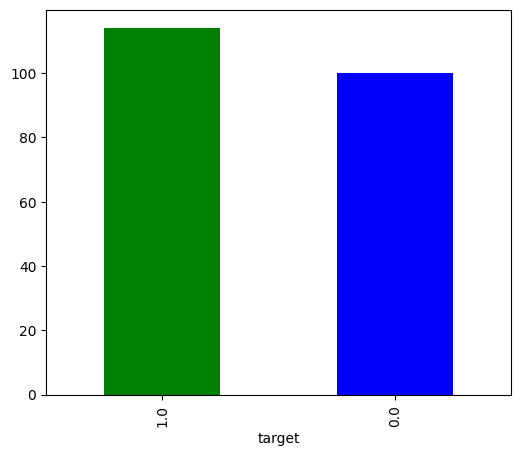

In [1]:
#Heart disease dataset (heartdisease3)
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
heart_disease = pd.read_csv('/kaggle/input/heartdisease3/heart-disease3.csv')
heart_disease.head()
heart_disease.replace('?', np.nan, inplace=True) #assign back
heart_disease.isnull().sum()
heart_disease.dropna(axis=0, inplace=True)
heart_disease.isnull().sum()
x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]
x.head()
y.head(), y.value_counts()
fig, ax = plt.subplots(figsize=(6,5))
y.value_counts().plot(kind='bar', color=["green", "blue"])
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,
test_size=0.25, random_state=100, shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X=x_train, y=y_train)
y_preds = clf.predict(X=x_test)
train_acc = clf.score(X=x_train, y=y_train)
print(f"The  model's accuracy on the training dataset is: {train_acc*100:.2f}%")
test_acc = clf.score(X=x_test, y=y_test)
print(f"The model's accuracy on the testing dataset is: {test_acc*100:.2f}%")

In [2]:
# import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# load dataset
spaceshipdata = pd.read_csv("/kaggle/input/spaceshipdata/spaceship-titanic.csv")
#drop missing values
spaceshipdata = spaceshipdata.dropna()
#drop columns that are strings and not useful
spaceshipdata = spaceshipdata.drop(['PassengerId', 'Name'], axis=1)
#encode categorical columns
label_encoder = LabelEncoder()
categorical_cols = ['HomePlanet', 'Cabin', 'Destination', 'VIP'] #include vip if exists
for col in categorical_cols:
    spaceshipdata[col] = label_encoder.fit_transform(spaceshipdata[col])
#convert target to numeric
spaceshipdata['Transported'] = spaceshipdata['Transported'].astype(int)
#define features and target
X = spaceshipdata.drop('Transported', axis=1)
y = spaceshipdata['Transported']
#train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=100)
#train random forest
model = RandomForestClassifier(random_state=100)
model.fit(X_train, y_train)
#evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.78


In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,
test_size=0.25, random_state=100, shuffle=False)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X=x_train, y=y_train)
y_preds = clf.predict(X=x_test)


ValueError: Found input variables with inconsistent numbers of samples: [214, 6606]

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

#load dataset
df = pd.read_csv("/kaggle/input/spaceshipdata/spaceship-titanic.csv")
#drop rows where target is missing 
df = df.dropna(subset=['Transported'])
#drop irrelevant columns 
df = df.drop(['PassengerId', 'Name'], axis=1)
#separate features and target
X = df.drop('Transported', axis=1)
y = df['Transported'].astype(str).map({'True': 1, 'False': 0})
# remove rows that failed conversion
valid_idx = y.notnull()
X = X.loc[valid_idx]
y = y.loc[valid_idx].astype(int)
#identify column type
categorical_cols = X.select_dtypes(include=['object','bool']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
#pipelines
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])
#combine preprocessing 
preprocessor = ColumnTransformer([('num', numeric_pipeline, numerical_cols), ('cat', categorical_pipeline, categorical_cols)])
#full pipeline w/ model
model = Pipeline([('preprocessing',preprocessor), ('classifier', RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42))])
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Train
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

In [ ]:
import numpy as np # linear algebra 
import pandas as pd # data processing, CSV file  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# read the data
dframe = pd.read_csv("/kaggle/input/admission-predict-data/Admission_Predict.csv")
#take whitespace from column names 
dframe.columns = dframe.columns.str.strip()
#inspect the data 
print(dframe.head())
print("\nMissing values per column:\n", dframe.isnull().sum())
print("\nShape of dataset:", dframe.shape)

# drop the duplicated values of the chance of admit 
df = dframe.drop_duplicates(subset=["Chance of Admit"])
print("\nShape after dropping duplicates:", df.shape)
print(df.head())
#scatter plots
plt.subplot(1,2,1)
plt.scatter(df["Chance of Admit"], df["TOEFL Score"], color='blue', alpha=0.6)
plt.xlabel("Chance of Admit")
plt.ylabel("TOEFL Score")
plt.title("Chance of Admit vs TOEFL Score")
#scatter:chance of admit vs CGPA
plt.subplot(1,2,2)
plt.scatter(df["Chance of Admit"], df["CGPA"], color='green',alpha=0.6)
plt.xlabel("Chance of Admit")
plt.ylabel("CGPA")
plt.title("Chance of Admit vs CGPA")
plt.tight_layout()
plt.show()
# correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(dframe.iloc[:,1:].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")  # <-- fixed typo
plt.show()
#linear regression: CGPA -> Chance of Admit
linear_reg = LinearRegression()
#sklearn wants 2d array for features 
X = df["CGPA"].values.reshape(-1,1)
y = df["Chance of Admit"].values

print("Before fitting:")
print("X shape:", X.shape)
print("y shape:", y.shape)
#train model
linear_reg.fit(X,y)
#predictions
y_pred = linear_reg.predict(X)
#plot regression line
plt.scatter(X, y, color='blue', alpha=0.6, label="Actual")
plt.plot(X, y_pred, color='red', linewidth=2, label="Predicted")
plt.xlabel("CGPA")
plt.ylabel("Chance of Admit")
plt.title("Linear Regression: CGPA vs Chance of Admit")
plt.legend()
plt.show()
#print model coefficients
print(f"Linear Regression Coefficient: {linear_reg.coef_[0]:.4f}")
print(f"Linear Regression Intercept: {linear_reg.intercept_:.4f}")